# Proportional Navigation Playground

Interactively explore how the navigation gain **N** and the initial
conditions of the **pursuer** and **target** shape the intercept.

Drag the sliders in the last cell and watch:
- **Left plot** — the trajectories in the plane.
- **Right plot** — the line-of-sight (LOS) angle and flight-path angle over time.
  When the LOS angle *flattens* (constant bearing), the pursuer is on a
  collision course. Higher `N` flattens it faster.

In [1]:
%matplotlib inline
import importlib
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

# The simulator file is named 'pronav-test.py' (hyphen), so import it by path.
pronav = importlib.import_module('pronav-test')
simulate = pronav.simulate

## Plotting helper
Runs `simulate(...)` with the chosen parameters and draws both views.

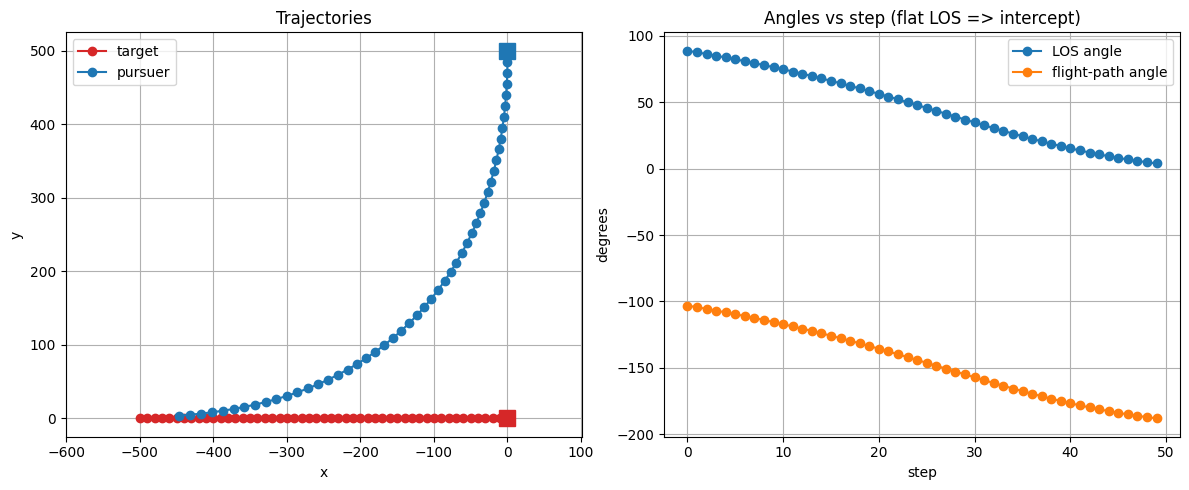

In [2]:
def plot_simulation(N=1.0, steps=50,
                    target_x0=0.0, target_y0=0.0, target_vx=-10.0, target_vy=0.0,
                    pursuer_x0=0.0, pursuer_y0=500.0, pursuer_vx=0.0, pursuer_vy=-15.0,
                    pursuer_fpa=-102.0):
    h = simulate(
        N=N, steps=steps,
        target_pos=(target_x0, target_y0), target_vel=(target_vx, target_vy),
        pursuer_pos=(pursuer_x0, pursuer_y0), pursuer_vel=(pursuer_vx, pursuer_vy),
        pursuer_fpa=pursuer_fpa,
    )

    fig, (ax_traj, ax_ang) = plt.subplots(1, 2, figsize=(12, 5))

    # Trajectories in the plane (squares mark the start positions).
    ax_traj.plot(h['target_x'], h['target_y'], 'o-', color='tab:red', label='target')
    ax_traj.plot(h['pursuer_x'], h['pursuer_y'], 'o-', color='tab:blue', label='pursuer')
    ax_traj.plot(target_x0, target_y0, 's', color='tab:red', markersize=12)
    ax_traj.plot(pursuer_x0, pursuer_y0, 's', color='tab:blue', markersize=12)
    ax_traj.set_title('Trajectories')
    ax_traj.set_xlabel('x'); ax_traj.set_ylabel('y')
    ax_traj.axis('equal'); ax_traj.legend(); ax_traj.grid(True)

    # Angles over time.
    steps_axis = range(len(h['losa']))
    ax_ang.plot(steps_axis, h['losa'], 'o-', label='LOS angle')
    ax_ang.plot(steps_axis, h['fpa'], 'o-', label='flight-path angle')
    ax_ang.set_title('Angles vs step (flat LOS => intercept)')
    ax_ang.set_xlabel('step'); ax_ang.set_ylabel('degrees')
    ax_ang.legend(); ax_ang.grid(True)

    plt.tight_layout()
    plt.show()

# Static example with the default scenario.
plot_simulation()

## Interactive controls
Compare `N=1` (LOS keeps drifting) against `N=5` (LOS flattens → intercept).

In [3]:
interact(
    plot_simulation,
    N=widgets.FloatSlider(value=1.0, min=0.0, max=10.0, step=0.5, description='N (gain)'),
    steps=widgets.IntSlider(value=10, min=5, max=60, step=1, description='steps'),
    target_x0=widgets.FloatSlider(value=0.0, min=-500, max=500, step=10, description='tgt x0'),
    target_y0=widgets.FloatSlider(value=0.0, min=-500, max=500, step=10, description='tgt y0'),
    target_vx=widgets.FloatSlider(value=-10.0, min=-30, max=30, step=1, description='tgt vx'),
    target_vy=widgets.FloatSlider(value=0.0, min=-30, max=30, step=1, description='tgt vy'),
    pursuer_x0=widgets.FloatSlider(value=0.0, min=-500, max=500, step=10, description='pur x0'),
    pursuer_y0=widgets.FloatSlider(value=500.0, min=-500, max=1000, step=10, description='pur y0'),
    pursuer_vx=widgets.FloatSlider(value=0.0, min=-30, max=30, step=1, description='pur vx'),
    pursuer_vy=widgets.FloatSlider(value=-15.0, min=-30, max=30, step=1, description='pur vy'),
    pursuer_fpa=widgets.FloatSlider(value=-102.0, min=-180, max=180, step=2, description='pur FPA'),
);

interactive(children=(FloatSlider(value=1.0, description='N (gain)', max=10.0, step=0.5), IntSlider(value=10, …